In [7]:

import os, math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import joblib
from pycocotools import mask as mask_util
from skimage.measure import regionprops, label, perimeter
import torchvision.transforms.functional as TF

# ---------- USER PATHS / CONFIG (edit these) ----------
MASKRCNN_WEIGHTS_PATH = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\analysis\feature_json_trained_maskrcnn.pth"    # <<< REPLACE with your mask-rcnn .pth
GB_MODEL_PATH          = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\analysis\GB_model_v1_unscaled.joblib"  # <<< REPLACE with your GB joblib path
TEST_IMAGE_PATH        = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\test_images\C1-C5_00020000.png"             # <<< REPLACE with your test image
# Optional: output path to save the overlaid image (set None to not save)
OUT_OVERLAY_PATH       = None   # e.g. r"C:\path\to\test_image_overlay.png"

# Model / inference params (tweak if you like)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MASK_THRESHOLD = 0.5    # binarize mask probability -> boolean
SCORE_THRESHOLD = 0.3   # drop low-confidence detections
NUM_OBJECT_CLASSES = 3  # other, rbc, cbc
MODEL_NUM_CLASSES = NUM_OBJECT_CLASSES + 1  # include background


In [8]:
# Feature columns in the same order as GB training
FEATURE_COLUMNS = [
    "original_area",
    "aspect_ratio",
    "circularity",
    "solidity",
    "mean_intensity",
    "std_intensity",
    "mrcnn_prob_other",
    "mrcnn_prob_rbc",
    "mrcnn_prob_cbc"
]

# Class name mapping (original category ids used in your pipeline: 0->other,1->rbc,2->cbc)
CLASS_ID_TO_NAME = {0: "other", 1: "rbc", 2: "cbc"}

# Colour mapping for overlay (RGB tuples 0-255)
CLASS_COLOR = {
    "other": (255, 255, 0),   # yellow
    "rbc":   (255,   0, 0),   # red
    "cbc":   (0,    0, 255)   # blue
}


In [9]:
# ---------- helper functions ----------
def get_maskrcnn_model(num_classes=MODEL_NUM_CLASSES, weights_path=None, device=DEVICE):
    """Instantiate Mask R-CNN, replace heads and load weights."""
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)
    # replace box predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    # replace mask predictor
    in_channels_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_channels_mask, hidden_layer, num_classes)

    if weights_path is not None:
        state = torch.load(weights_path, map_location=device)
        model.load_state_dict(state)
    model.to(device).eval()
    return model

def mask_iou_np(mask1, mask2):
    inter = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return float(inter)/float(union) if union>0 else 0.0

def compute_region_features(mask_bool, image_gray):
    """Compute requested features from binary mask and grayscale image (numpy arrays)."""
    if mask_bool.sum() == 0:
        return None
    lab = mask_bool.astype(np.uint8)
    props = regionprops(lab, intensity_image=image_gray)
    if len(props) == 0:
        return None
    r = props[0]
    area = float(r.area)
    minr, minc, maxr, maxc = r.bbox
    w = float(maxc - minc)
    h = float(maxr - minr)
    aspect_ratio = (w / h) if h > 0 else 0.0
    # perimeter: regionprops provides perimeter attribute usually
    try:
        per = float(r.perimeter)
    except Exception:
        per = float(perimeter(mask_bool, neighbourhood=8))
    circularity = (4 * math.pi * area / (per * per)) if per > 0 else 0.0
    solidity = float(r.solidity) if hasattr(r, "solidity") else 0.0
    pixels = image_gray[mask_bool]
    mean_intensity = float(np.mean(pixels)) if pixels.size>0 else 0.0
    std_intensity = float(np.std(pixels)) if pixels.size>0 else 0.0

    return {
        "original_area": area,
        "aspect_ratio": aspect_ratio,
        "circularity": circularity,
        "solidity": solidity,
        "mean_intensity": mean_intensity,
        "std_intensity": std_intensity
    }



In [10]:
def build_mrcnn_prob_vector(pred_label_mapped, pred_score, num_object_classes=NUM_OBJECT_CLASSES):
    """
    Build the heuristic mrcnn_prob_* vector used earlier:
    place pred_score at the predicted class index, distribute remaining mass uniformly.
    pred_label_mapped: 0..(num_object_classes-1)
    """
    if num_object_classes == 1:
        return np.array([1.0])
    probs = np.full((num_object_classes,), (1.0 - pred_score) / (num_object_classes - 1), dtype=float)
    if 0 <= pred_label_mapped < num_object_classes:
        probs[pred_label_mapped] = pred_score
    else:
        probs = np.full((num_object_classes,), 1.0/num_object_classes)
    return probs

def overlay_masks_on_image(pil_img, masks_info, alpha=0.5):
    """
    overlays masks_info onto PIL image and returns a PIL image with RGBA blending.
    masks_info: list of dict with keys: 'mask' (HxW bool), 'class_name' (str)
    """
    img = pil_img.convert("RGBA")
    arr = np.array(img)  # H W 4
    H, W = arr.shape[:2]
    overlay = np.zeros((H, W, 4), dtype=np.uint8)  # RGBA overlay

    for info in masks_info:
        mask = info['mask']
        cls = info['class_name']
        color = CLASS_COLOR.get(cls, (255,0,255))
        # mask might be boolean array; create an RGBA layer for this mask
        col_layer = np.zeros((H, W, 4), dtype=np.uint8)
        col_layer[...,0] = color[0]
        col_layer[...,1] = color[1]
        col_layer[...,2] = color[2]
        col_layer[...,3] = (mask.astype(np.uint8) * int(255 * alpha)).astype(np.uint8)
        # add by alpha compositing onto overlay (simple max will work for semi-transparent stacking)
        overlay[..., :3] = np.maximum(overlay[..., :3], col_layer[..., :3] * (col_layer[...,3:]/255.0))
        overlay[..., 3] = np.maximum(overlay[..., 3], col_layer[..., 3])

    # composite overlay onto original
    # convert overlay to PIL image and alpha-composite
    overlay_pil = Image.fromarray(overlay, mode="RGBA")
    composed = Image.alpha_composite(img, overlay_pil)
    return composed


In [11]:
# ---------- main pipeline ----------
def run_inference_and_overlay(test_image_path,
                              maskrcnn_weights_path=MASKRCNN_WEIGHTS_PATH,
                              gb_model_path=GB_MODEL_PATH,
                              score_thresh=SCORE_THRESHOLD,
                              mask_thresh=MASK_THRESHOLD,
                              save_overlay_path=OUT_OVERLAY_PATH):
    # load models
    print("Loading Mask R-CNN...")
    mask_model = get_maskrcnn_model(num_classes=MODEL_NUM_CLASSES, weights_path=maskrcnn_weights_path, device=DEVICE)
    print("Loading GB model...")
    gb = joblib.load(gb_model_path)

    # load image
    pil = Image.open(test_image_path).convert("RGB")
    W, H = pil.size
    img_arr = np.array(pil)
    # grayscale for intensity features
    if img_arr.ndim == 3:
        img_gray = (0.2989 * img_arr[:,:,0] + 0.5870 * img_arr[:,:,1] + 0.1140 * img_arr[:,:,2]).astype(np.float32)
    else:
        img_gray = img_arr.astype(np.float32)

    # prepare tensor
    img_tensor = TF.to_tensor(pil).to(DEVICE)

    # run inference
    with torch.no_grad():
        outputs = mask_model([img_tensor])
    out = outputs[0]
    pred_masks = out.get('masks')      # (N,1,H,W)
    pred_labels = out.get('labels')    # tensor N
    pred_scores = out.get('scores')    # tensor N

    if pred_masks is None or len(pred_masks) == 0:
        print("No detections.")
        return pil

    pred_masks_np = pred_masks.cpu().numpy()  # N,1,H,W
    pred_labels_np = pred_labels.cpu().numpy() if pred_labels is not None else np.array([])
    pred_scores_np = pred_scores.cpu().numpy() if pred_scores is not None else np.array([])

    masks_info_for_overlay = []
    results = []  # for debug

    for i in range(pred_masks_np.shape[0]):
        score = float(pred_scores_np[i]) if i < len(pred_scores_np) else 1.0
        if score < score_thresh:
            continue
        mask_prob = pred_masks_np[i,0]    # H x W floats 0..1
        mask_bin = (mask_prob >= mask_thresh)
        if mask_bin.sum() == 0:
            continue

        # compute requested features
        feats = compute_region_features(mask_bin, img_gray)
        if feats is None:
            continue

        # predicted label mapping: torchvision returns labels 1..C (background excluded)
        pred_label_raw = int(pred_labels_np[i]) if i < len(pred_labels_np) else -1
        pred_label_mapped = pred_label_raw - 1  # map to 0..(num_objects-1)

        # build mrcnn_prob vector (heuristic)
        probs = build_mrcnn_prob_vector(pred_label_mapped, score, NUM_OBJECT_CLASSES)
        # pack feature vector in the same order as FEATURE_COLUMNS
        fv = [
            feats["original_area"],
            feats["aspect_ratio"],
            feats["circularity"],
            feats["solidity"],
            feats["mean_intensity"],
            feats["std_intensity"],
            float(probs[0]),
            float(probs[1]),
            float(probs[2])
        ]
        # GB predict (if your GB expects a 2D array)
        pred_final = gb.predict([fv])[0]
        pred_proba = gb.predict_proba([fv])[0] if hasattr(gb, "predict_proba") else None

        class_name = CLASS_ID_TO_NAME.get(int(pred_final), "other")

        results.append({
            "pred_index": i,
            "pred_label_maskrcnn": pred_label_mapped,
            "pred_score_maskrcnn": score,
            "gb_pred": int(pred_final),
            "gb_proba": pred_proba,
            "features": feats
        })

        # prepare overlay info
        masks_info_for_overlay.append({
            "mask": mask_bin,
            "class_name": class_name
        })

    # create final overlayed image
    overlaid = overlay_masks_on_image(pil, masks_info_for_overlay, alpha=0.45)

    # show and optionally save
    plt.figure(figsize=(8,8))
    plt.imshow(overlaid)
    plt.axis("off")
    plt.title(f"GB final predictions overlay on {os.path.basename(test_image_path)}")
    plt.show()

    if save_overlay_path is not None:
        overlaid.save(save_overlay_path)
        print("Saved overlay to", save_overlay_path)

    return results, overlaid


Loading Mask R-CNN...


C:\Users\shiva\AppData\Local\Temp\ipykernel_11188\1092999991.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(weights_path, map_location=device)


Loading GB model...


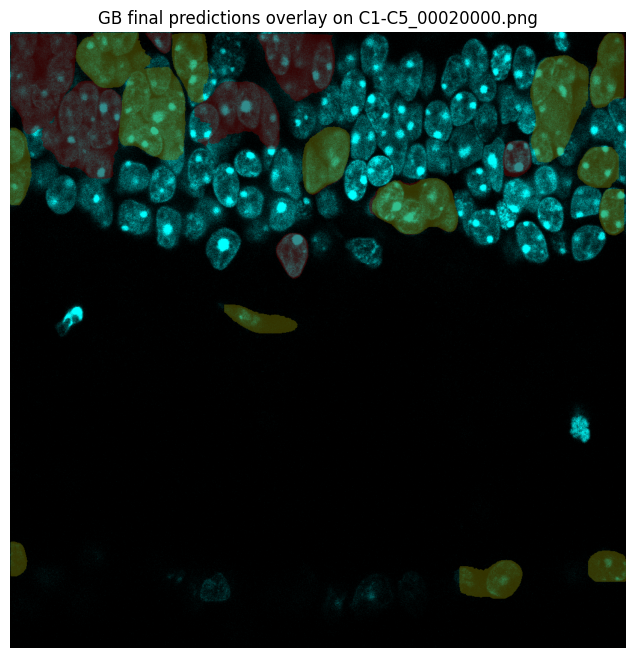

Per-instance results (first 10):
{'pred_index': 0, 'pred_label_maskrcnn': 0, 'pred_score_maskrcnn': 0.8185004591941833, 'gb_pred': 0, 'gb_proba': array([0.88843537, 0.10224615, 0.00931847]), 'features': {'original_area': 2968.0, 'aspect_ratio': 1.2115384615384615, 'circularity': 0.8781896701933335, 'solidity': 0.988674217188541, 'mean_intensity': 15.161014556884766, 'std_intensity': 17.38629913330078}}
{'pred_index': 1, 'pred_label_maskrcnn': 1, 'pred_score_maskrcnn': 0.6698137521743774, 'gb_pred': 1, 'gb_proba': array([0.27920761, 0.70449669, 0.0162957 ]), 'features': {'original_area': 7895.0, 'aspect_ratio': 1.2967032967032968, 'circularity': 0.7429501192897591, 'solidity': 0.9447170037094651, 'mean_intensity': 40.209163665771484, 'std_intensity': 24.24862289428711}}
{'pred_index': 2, 'pred_label_maskrcnn': 0, 'pred_score_maskrcnn': 0.660744845867157, 'gb_pred': 0, 'gb_proba': array([0.82088068, 0.14585228, 0.03326704]), 'features': {'original_area': 1328.0, 'aspect_ratio': 0.4827586

In [12]:
res, overlaid_img = run_inference_and_overlay(TEST_IMAGE_PATH,
                                                  maskrcnn_weights_path=MASKRCNN_WEIGHTS_PATH,
                                                  gb_model_path=GB_MODEL_PATH,
                                                  score_thresh=0.3,
                                                  mask_thresh=0.5,
                                                  save_overlay_path=OUT_OVERLAY_PATH)
print("Per-instance results (first 10):")
for r in res[:10]:
  print(r)


Loading Mask R-CNN...


C:\Users\shiva\AppData\Local\Temp\ipykernel_11188\1092999991.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(weights_path, map_location=device)


Loading GB model...


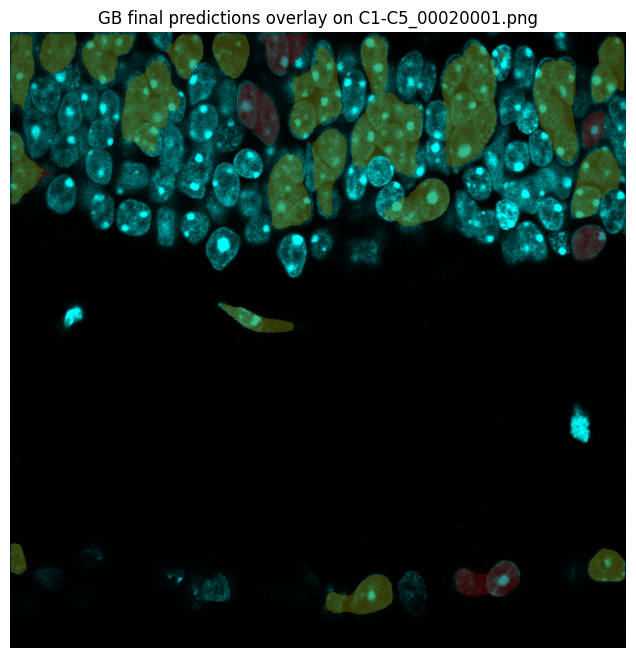

In [17]:
res, overlaid_img = run_inference_and_overlay(r'C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\test_images\C1-C5_00020001.png',
                                                  maskrcnn_weights_path=MASKRCNN_WEIGHTS_PATH,
                                                  gb_model_path=GB_MODEL_PATH,
                                                  score_thresh=0.3,
                                                  mask_thresh=0.95,
                                                  save_overlay_path=OUT_OVERLAY_PATH)

Loading Mask R-CNN...


C:\Users\shiva\AppData\Local\Temp\ipykernel_11188\1092999991.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(weights_path, map_location=device)


Loading GB model...


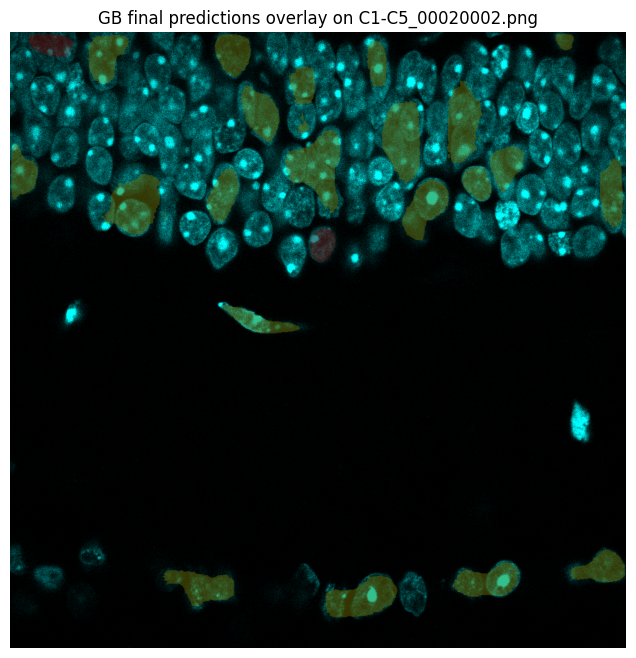

In [19]:
res, overlaid_img = run_inference_and_overlay(r'C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\test_images\C1-C5_00020002.png',
                                                  maskrcnn_weights_path=MASKRCNN_WEIGHTS_PATH,
                                                  gb_model_path=GB_MODEL_PATH,
                                                  score_thresh=0.3,
                                                  mask_thresh=0.99,
                                                  save_overlay_path=OUT_OVERLAY_PATH)